# Baseline results - precision and recall

## Python library imports

In [1]:
import Common
import matplotlib.pyplot as pyplt
import numpy as np
import pandas as pd
import statistics

## Read TFlite index file and FLTS dataset 

In [8]:
model_index_to_species = Common.read_floralens_model_labels()

In [3]:
dset_data = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')
dset_data = dset_data[dset_data.set == 'TEST']
dset_data

,species,filename,url,source_url,set,repos,gbif_id
0,Acacia dealbata,Acacia_dealbata_1945424512_1.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1945424512,TEST,iNaturalist,1.945425e+09
1,Acacia dealbata,Acacia_dealbata_2974327900_1.jpg,https://storage.googleapis.com/floraondata/Pla...,https://www.gbif.org/occurrence/2974327900,TEST,Pl@ntNet,2.974328e+09
2,Acacia dealbata,Acacia_dealbata_1946199420_3.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1946199420,TEST,iNaturalist,1.946199e+09
3,Acacia dealbata,Acacia_dealbata_1945436102_1.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1945436102,TEST,iNaturalist,1.945436e+09
4,Acacia dealbata,Acacia_dealbata_1805367892_1.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1805367892,TEST,iNaturalist,1.805368e+09
...,...,...,...,...,...,...,...
293459,Zostera noltii,Zostera_noltii_2242774794_1.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/2242774794,TEST,iNaturalist,2.242775e+09
293460,Zostera noltii,Zostera_noltii_1972305757_1.jpg,https://storage.googleapis.com/floraondata/Obs...,https://www.gbif.org/occurrence/1972305757,TEST,Observation.org,1.972306e+09
293461,Zostera noltii,Zostera_noltii_1931477974_1.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1931477974,TEST,iNaturalist,1.931478e+09
293462,Zostera noltii,Zostera_noltii_3112502324_2.jpg,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/3112502324,TEST,iNaturalist,3.112502e+09


## Compute precision and recall results

In [4]:
# Extract detailed results for FLTS
print('unzipping detailed results ...')
Common.unzip_archive('../floralens/detailed-results.zip')

print('calculating precision and recall results ...')
confidence_levels = np.arange(0.0, 1.01, 0.01)[::-1]
N_BINS = len(confidence_levels)
TP =  [[0] * len(model_index_to_species) for i in range(N_BINS) ]
FP =  [[0] * len(model_index_to_species)for i in range(N_BINS) ]
FN =  [[0] * len(model_index_to_species)for i in range(N_BINS) ]

count = 0
for img in dset_data.itertuples():
    with open('detailed-results/'+img.filename+'.score.txt') as score_file_inp:
        img_scores = np.array([ float(line.strip()) for line in score_file_inp.readlines()])
    img_species_idx = model_index_to_species.index(img.species)
    ranked_species_indexes = img_scores.argsort()[::-1]
    for i,CONFIDENCE_LEVEL in enumerate(confidence_levels):
        for s_idx in ranked_species_indexes:
            score = img_scores[s_idx]
            if score <= CONFIDENCE_LEVEL:
                break
            if s_idx != img_species_idx:
                FP[i][s_idx] += 1
    species_score = img_scores[img_species_idx]
    for i,CONFIDENCE_LEVEL in enumerate(confidence_levels):
        if species_score > CONFIDENCE_LEVEL:
            #print(img.species, 'TP', species_score, img_species_idx, CONFIDENCE_LEVEL)
            TP[i][img_species_idx] += 1
        else:
            #print(img.species, 'FN', species_score, img_species_idx, CONFIDENCE_LEVEL)
            FN[i][img_species_idx] += 1
print('done')

# Clean up 
Common.cleanup_dir('detailed-results')
print('cleaning up')


unzipping detailed results ...
calculating precision and recall results ...
done
cleaning up


## Derive plot data

In [5]:
results = []
for i, cl in enumerate(confidence_levels):
    precision = [ 0 ] * len(model_index_to_species)
    recall = [ 0 ] * len(model_index_to_species)
    for j,s in enumerate(model_index_to_species):
        if TP[i][j] == 0 and FP[i][j] == 0:
            precision[j] = 1
        else:
            precision[j] = TP[i][j] / (TP[i][j] + FP[i][j])
        #print(s,TP[i][j],FP[i][j],FN[i][j])
        recall[j] = TP[i][j] / (TP[i][j] + FN[i][j]) 
    results.append(
        [cl, statistics.mean(precision), statistics.mean(recall)]
    )
plot_data = pd.DataFrame(results[::-1], columns=['Confidence', 'Precision', 'Recall'])
plot_data

,Confidence,Precision,Recall
0,0.00,0.052486,0.951463
1,0.01,0.161069,0.903411
2,0.02,0.258053,0.868357
3,0.03,0.305319,0.850233
4,0.04,0.361790,0.829703
...,...,...,...
96,0.96,0.980430,0.140197
97,0.97,0.984731,0.112973
98,0.98,0.986346,0.090934
99,0.99,0.993852,0.053056


## Precision-recall curve plot

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


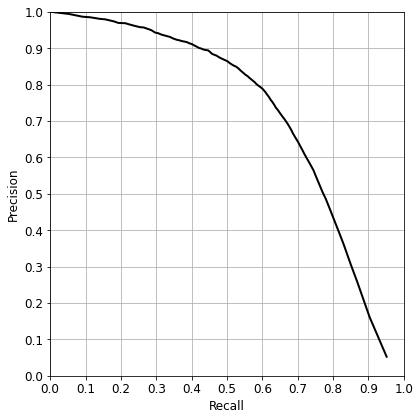

In [6]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (6,6)
plt = plot_data.plot.line(x='Recall',y=['Precision'],color=['black'],linewidth=2)
plt.set_xlim([0.00,1.0])
plt.set_xticks([0.00,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.set_ylim([0.00,1.0])
plt.set_yticks([0.00,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.set_xlabel('Recall')
plt.set_ylabel('Precision')
plt.grid(axis='both')
plt.get_figure().tight_layout()
plt.get_legend().remove()
plt.get_figure().savefig("plot_images/prec_recall_plot_2.pdf")

## Precision and recall per confidence level

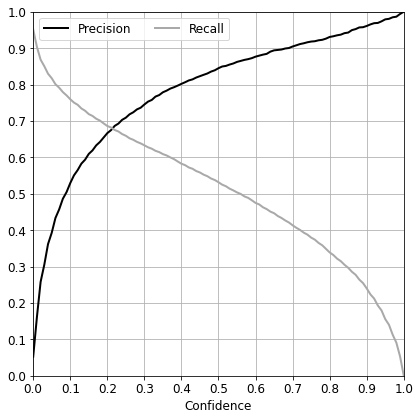

In [7]:
plt = plot_data.plot.line(x='Confidence',y=['Precision', 'Recall'],color=['black','darkgray'],linewidth=2)
plt.legend(loc='upper left',ncol=3)
plt.set_xlim([0.00,1.0])
plt.set_xticks([0.00,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.set_ylim([0.00,1.0])
plt.set_yticks([0.00,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.grid(axis='both')
plt.get_figure().tight_layout()
plt.get_figure().savefig("plot_images/prec_recall_plot_1.pdf")